# mcp Basics

# keys import

In [22]:
import os
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")

# Model Loading

In [23]:
import os
from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch  # updated at 1.0

#llm
##################
llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={"headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}},
)
response = llm.invoke("What is the color of the sky answer in one word?")
print(response.content)

# llm
####################
# Initialize the model (you can use models like gemini-2.5-flash or gemini-pro)
llmg = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=GOOGLE_API_KEY)
response = llmg.invoke("What is the color of the sky answer in one word?")
print(response.content)



blue
Blue


# for runing asynic in notebook

In [2]:
import sys
import asyncio

# =============================================================================
# Windows + Jupyter + MCP Fix: Async Subprocess Support
# =============================================================================
# Problem: Windows SelectorEventLoop doesn't support subprocess creation
# Solution: Replace the running event loop with ProactorEventLoop
# =============================================================================

if sys.platform == "win32":
    # Step 1: Set ProactorEventLoop policy for subprocess support
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

    # Step 2: Close and replace Jupyter's existing event loop
    # Jupyter creates a SelectorEventLoop before our code runs, so we must replace it
    try:
        loop = asyncio.get_running_loop()
        # We can't replace a running loop, but we can verify it's the right type
        if not isinstance(loop, asyncio.ProactorEventLoop):
            print("WARNING: Event loop is already running and is not ProactorEventLoop")
            print("You may need to restart the kernel for full compatibility")
    except RuntimeError:
        # No loop is running, create a new ProactorEventLoop
        loop = asyncio.ProactorEventLoop()
        asyncio.set_event_loop(loop)

    # Step 3: Fix stderr for subprocess compatibility
    # Jupyter's sys.stderr doesn't have fileno(), which breaks subprocess.Popen
    if "ipykernel" in sys.modules:
        import io
        # Replace Jupyter's stderr with the original stderr or a null stream
        if hasattr(sys, '__stderr__') and sys.__stderr__ is not None:
            sys.stderr = sys.__stderr__
        else:
            # Fallback: use devnull if __stderr__ is not available
            sys.stderr = open('nul', 'w')  # 'nul' is Windows equivalent of /dev/null

print(f"Event loop type: {type(asyncio.get_event_loop()).__name__}")
print(f"Event loop policy: {type(asyncio.get_event_loop_policy()).__name__}")
print("Windows MCP subprocess support configured successfully!")

You may need to restart the kernel for full compatibility
Event loop type: _WindowsSelectorEventLoop
Event loop policy: WindowsProactorEventLoopPolicy
Windows MCP subprocess support configured successfully!


# Set up MCP Server object (Optional)

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "mcp_server": {
            "transport": "stdio",
            "command" : "python",
            "args": ["resources/2.1_mcp_server.py"]
        }
    }
)

# set up MCP client object

In [95]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "my_server": {
            "url": "http://localhost:8000/mcp",
            "transport": "streamable_http",
        }
    }
)

In [47]:
# get tools
tools = await client.get_tools()
print(tools)

tools = await client.get_tools()
print([t.name for t in tools])

resources = await client.get_resources("my_server")
print(resources)


prompt = await client.get_prompt("my_server", "prompt")
print(prompt)


[StructuredTool(name='search_web', description='Search the web for information', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'search_webArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x0000025F438EA5C0>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000025F46A63BA0>)]
['search_web']
[Blob 2608230498384]
[HumanMessage(content='\n    You are a helpful assistant that answers user questions about LangChain, LangGraph and LangSmith.\n\n    You can use the following tools/resources to answer user questions:\n    - search_web: Search the web for information\n    - github_file: Access the langchain-ai repo files\n\n    If the user asks a question that is not related to LangChain, LangGraph or LangSmith, you should say "I\'m sorry, I can only answer questions about LangChain, LangGraph and LangSmith."\n\n    You may try m

## tools

In [5]:
tools = await client.get_tools()

search_tool = next(
    t for t in tools
    if t.name == "search_web"
)

result = await search_tool.ainvoke(
    {"query": "latest LangGraph features"}
)

print(result)

[{'type': 'text', 'text': '{\n  "query": "latest LangGraph features",\n  "follow_up_questions": null,\n  "answer": null,\n  "images": [],\n  "results": [\n    {\n      "url": "https://medium.com/@romerorico.hugo/langgraph-1-0-released-no-breaking-changes-all-the-hard-won-lessons-8939d500ca7c",\n      "title": "LangGraph 1.0: Changes Guide for AI Engineers - Medium",\n      "content": "LangGraph 1.0 released in October 2025. Discover production-ready features: durable execution, streaming, human oversight & memory",\n      "score": 0.74697095,\n      "raw_content": null\n    },\n    {\n      "url": "https://www.reddit.com/r/LangChain/comments/1njlqfq/new_langgraph_and_langchain_v1",\n      "title": "New langgraph and langchain v1 - Reddit",\n      "content": "The LangChain team dropped new features last week. Here\'s a quick look at what\'s new: New create_agent Primitive: Easily create agents with",\n      "score": 0.7018975,\n      "raw_content": null\n    },\n    {\n      "url": "htt

In [6]:
result

[{'type': 'text',
  'text': '{\n  "query": "latest LangGraph features",\n  "follow_up_questions": null,\n  "answer": null,\n  "images": [],\n  "results": [\n    {\n      "url": "https://medium.com/@romerorico.hugo/langgraph-1-0-released-no-breaking-changes-all-the-hard-won-lessons-8939d500ca7c",\n      "title": "LangGraph 1.0: Changes Guide for AI Engineers - Medium",\n      "content": "LangGraph 1.0 released in October 2025. Discover production-ready features: durable execution, streaming, human oversight & memory",\n      "score": 0.74697095,\n      "raw_content": null\n    },\n    {\n      "url": "https://www.reddit.com/r/LangChain/comments/1njlqfq/new_langgraph_and_langchain_v1",\n      "title": "New langgraph and langchain v1 - Reddit",\n      "content": "The LangChain team dropped new features last week. Here\'s a quick look at what\'s new: New create_agent Primitive: Easily create agents with",\n      "score": 0.7018975,\n      "raw_content": null\n    },\n    {\n      "url": "h

In [7]:
tools

[StructuredTool(name='search_web', description='Search the web for information', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'search_webArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x0000025F438EA5C0>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000025F43BE0680>)]

In [8]:
# get tools
tools = await client.get_tools()

In [9]:
tools

[StructuredTool(name='search_web', description='Search the web for information', args_schema={'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'search_webArguments', 'type': 'object'}, handle_tool_error=<function _handle_mcp_tool_error at 0x0000025F438EA5C0>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x0000025F43C68E00>)]

## resources

In [19]:
tools = await client.get_tools()
print([t.name for t in tools])

resources = await client.get_resources("my_server")
print(resources)


['search_web']
[Blob 2608182321200]


In [20]:
resources

[Blob 2608182321200]

In [21]:
# 2. Loop through the list and extract the hidden data
for blob in resources:
    # Use .data to get the string content directly
    text_content = blob.data 
    
    print("--- Found Resource Data ---")
    print(text_content)

--- Found Resource Data ---
# LangChain MCP Adapters

This library provides a lightweight wrapper that makes [Anthropic Model Context Protocol (MCP)](https://modelcontextprotocol.io/introduction) tools compatible with [LangChain](https://github.com/langchain-ai/langchain) and [LangGraph](https://github.com/langchain-ai/langgraph).

![MCP](static/img/mcp.png)

> [!note]
> A JavaScript/TypeScript version of this library is also available at [langchainjs](https://github.com/langchain-ai/langchainjs/tree/main/libs/langchain-mcp-adapters/).

## Features

- 🛠️ Convert MCP tools into [LangChain tools](https://python.langchain.com/docs/concepts/tools/) that can be used with [LangGraph](https://github.com/langchain-ai/langgraph) agents
- 📦 A client implementation that allows you to connect to multiple MCP servers and load tools from them

## Installation

```bash
pip install langchain-mcp-adapters
```

## Quickstart

Here is a simple example of using the MCP tools with a LangGraph agent.

```ba

## prompt

In [15]:
prompt = await client.get_prompt("my_server", "prompt")
# await client.get_resources("my_server")

In [36]:
prompt

[HumanMessage(content='\n    You are a helpful assistant that answers user questions about LangChain, LangGraph and LangSmith.\n\n    You can use the following tools/resources to answer user questions:\n    - search_web: Search the web for information\n    - github_file: Access the langchain-ai repo files\n\n    If the user asks a question that is not related to LangChain, LangGraph or LangSmith, you should say "I\'m sorry, I can only answer questions about LangChain, LangGraph and LangSmith."\n\n    You may try multiple tool and resource calls to answer the user\'s question.\n\n    You may also ask clarifying questions to the user to better understand their question.\n    ', additional_kwargs={}, response_metadata={})]

In [48]:
print(prompt[0].content)


    You are a helpful assistant that answers user questions about LangChain, LangGraph and LangSmith.

    You can use the following tools/resources to answer user questions:
    - search_web: Search the web for information
    - github_file: Access the langchain-ai repo files

    If the user asks a question that is not related to LangChain, LangGraph or LangSmith, you should say "I'm sorry, I can only answer questions about LangChain, LangGraph and LangSmith."

    You may try multiple tool and resource calls to answer the user's question.

    You may also ask clarifying questions to the user to better understand their question.
    


# langchain Agent only

In [28]:
from langchain.agents import create_agent

llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={"headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}},
)

# 3. Create the agent by passing the 'llm' variable into the model parameter
agent = create_agent(
    model=llm,          # Pass the llm object here instead of a "string"
    tools=tools,        # The tool list loaded from your server
    system_prompt=prompt[0].content  # The text rules from the server prompt
)

# 4. Ask the agent a question
response = await agent.ainvoke(
    {"messages": "What is LangGraph and what tools do you have answer in two lines only"}
)
print(response)

{'messages': [HumanMessage(content='What is LangGraph and what tools do you have answer in two lines only', additional_kwargs={}, response_metadata={}, id='174ddadd-0032-436e-ba44-c2f20186388f'), AIMessage(content='LangGraph is a library for building stateful, graph‑based agents in the LangChain ecosystem.  \nI can use the search_web and github_file tools to retrieve information.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-11T15:34:37.670633799Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2391835590, 'load_duration': None, 'prompt_eval_count': 419, 'prompt_eval_duration': None, 'eval_count': 182, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019eb75a-7e00-78f3-b8f8-cdd3d2f88241-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 419, 'output_tokens': 182, 'total_tokens': 601})]}


In [99]:
print(response['messages'][1].content)

LangGraph is a framework for building stateful, multi‑agent applications using graphs of LLMs and tools.  
I have access to the `search_web` and `github_file` tools to retrieve information.


In [96]:
response

{'messages': [HumanMessage(content='What is LangGraph and what tools do you have answer in two lines only', additional_kwargs={}, response_metadata={}, id='f8a3e8a6-67de-44b3-b294-9a2976eb779e'),
  AIMessage(content='LangGraph is a framework for building stateful, multi‑agent applications using graphs of LLMs and tools.  \nI have access to the `search_web` and `github_file` tools to retrieve information.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-11T15:54:24.84971765Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2848473965, 'load_duration': None, 'prompt_eval_count': 419, 'prompt_eval_duration': None, 'eval_count': 129, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019eb76c-98ce-7a93-8629-dfd872e5aeb2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 419, 'output_tokens': 129, 'total_tokens': 548})]}

In [ ]:
{'messages': [HumanMessage(content='Tell me about the langchain-mcp-adapters library', additional_kwargs={}, response_metadata={}, id='909094c8-80b7-4c1d-8ffd-54523c01c85e'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 271, 'total_tokens': 363, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D6z41dMta5OOaEBWSxZUYpU6l2w6g', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c3d6c-d504-7092-b936-8cd8dca0251e-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'langchain-mcp-adapters'}, 'id': 'call_iuJgrg5KmF2lB4Fr3bw7XpfS', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 271, 'output_tokens': 92, 'total_tokens': 363, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}}),
              ToolMessage(content=[{'type': 'text', 'text': '{\n  "query": "langchain-mcp-adapters",\n  "response_time": 0.66,\n  "follow_up_questions": null,\n  "answer": null,\n  "images": [],\n  "results": [\n    {\n      "url": "https://changelog.langchain.com/announcements/mcp-adapters-for-langchain-and-langgraph",\n      "title": "MCP Adapters for LangChain and LangGraph",\n      "content": "# LangChain Changelog. Sign up for our newsletter to stay up to date. # MCP Adapters for LangChain and LangGraph. The **LangChain MCP Adapters** is a package that makes it easy to use **Anthropic Model Context Protocol (MCP) tools** with LangChain & LangGraph. * Converts **MCP tools** into **LangChain- & LangGraph-compatible tools**. * Enables interaction with tools across multiple **MCP servers**. * Seamlessly integrates the **hundreds of tool servers** already published into LangGraph Agents. ### Why use MCP Adapters:. This adapter makes it simple to connect LangChain and LangGraph with the growing ecosystem of MCP tool servers. Instead of manually adapting each tool, you can now integrate them seamlessly. It also allows agents to pull from multiple MCP servers at once, making it easier to combine different tools for more powerful applications. MCP is gaining serious traction, and this adapter helps LangGraph agents take full advantage. ##### Subscribe to updates.",\n      "score": 0.99999535,\n      "raw_content": null\n    },\n    {\n      "url": "https://medium.com/@deepakkamboj/the-complete-guide-to-langchain-mcp-adapters-bridging-langchain-and-model-context-protocol-3f5507cbd3ca",\n      "title": "The Complete Guide to langchain-mcp-adapters: Bridging ... - Medium",\n      "content": "This open-source package eliminates the complexity of manual tool integration by providing seamless conversion between MCP tools and LangChain-compatible tools, enabling developers to tap into hundreds of existing MCP servers without writing custom adapters. from langchain_mcp_adapters.client import MultiServerMCPClientfrom langchain.agents import create_agentclient = MultiServerMCPClient({ \\"math\\": { \\"transport\\": \\"stdio\\", \\"command\\": \\"python\\", \\"args\\": [\\"/path/to/math_server.py\\"] }, \\"weather\\": { \\"transport\\": \\"streamable_http\\", \\"url\\": \\"http://localhost:8000/mcp\\" }})# Load all tools from all serverstools = await client.get_tools()# Create an agent with these toolsagent = create_agent(\\"claude-sonnet-4-5-20250929\\", tools)# Use the agentresponse = await agent.ainvoke({ \\"messages\\": [{\\"role\\": \\"user\\", \\"content\\": \\"what\'s (3 + 5) x 12?\\"}]}). from langchain_mcp_adapters.client import MultiServerMCPClientfrom langgraph.graph import StateGraph, MessagesState, STARTfrom langgraph.prebuilt import ToolNode, tools_conditionfrom langchain.chat_models import init_chat_modelmodel = init_chat_model(\\"openai:gpt-4.1\\")client = MultiServerMCPClient({ \\"math\\": { \\"command\\": \\"python\\", \\"args\\": [\\"./examples/math_server.py\\"], \\"transport\\": \\"stdio\\" }, \\"weather\\": { \\"url\\": \\"http://localhost:8000/mcp\\", \\"transport\\": \\"streamable_http\\" }})tools = await client.get_tools()def call_model(state: MessagesState): response = model.bind_tools(tools).invoke(state[\\"messages\\"]) return {\\"messages\\": response}builder = StateGraph(MessagesState)builder.add_node(call_model)builder.add_node(ToolNode(tools))builder.add_edge(START, \\"call_model\\")builder.add_conditional_edges(\\"call_model\\", tools_condition)builder.add_edge(\\"tools\\", \\"call_model\\").",\n      "score": 0.9999932,\n      "raw_content": null\n    },\n    {\n      "url": "https://reference.langchain.com/python/langchain_mcp_adapters/",\n      "title": "langchain-mcp-adapters",\n      "content": "This module provides functionality to convert MCP prompt messages into LangChain message objects, handling both user and assistant message types. FUNCTION",\n      "score": 0.9999852,\n      "raw_content": null\n    },\n    {\n      "url": "https://www.npmjs.com/package/@langchain/mcp-adapters",\n      "title": "langchain/mcp-adapters - NPM",\n      "content": "The library allows you to connect to one or more MCP servers and load tools from them, without needing to manage your own MCP client instances. // Whether to throw on errors if a tool fails to load (optional, default: true). // Whether to prefix tool names with the server name (optional, default: false). // Whether to throw errors if a tool fails to load (optional, default: true). When calling tools from the `camera` MCP server, the following `outputHandling` config will be used:. Similarly, when calling tools on the `microphone` MCP server, the following `outputHandling` config will be used:. You can include a `defaultToolTimeout` field in the server config to set the timeout for all tools for that server, or globally for the entire client by setting it in the top-level config. For secure MCP servers that require OAuth 2.0 authentication, you can use the `authProvider` option instead of manually managing headers. const tools = await client.getTools(); // Only tools from \\"working-server\\".",\n      "score": 0.99997294,\n      "raw_content": null\n    },\n    {\n      "url": "https://docs.langchain.com/oss/python/langchain/mcp",\n      "title": "Model Context Protocol (MCP) - Docs by LangChain",\n      "content": "from dataclasses import dataclass from  dataclasses import  dataclassfrom langchain_mcp_adapters.client import MultiServerMCPClient from langchain_mcp_adapters.client import  MultiServerMCPClientfrom langchain_mcp_adapters.interceptors import MCPToolCallRequest from langchain_mcp_adapters.interceptors import  MCPToolCallRequestfrom langchain.agents import create_agent from langchain.agents import  create_agent @dataclass @dataclassclass Context: class  Context: user_id: str user_id: str api_key: str api_key: str async def inject_user_context(async  def  inject_user_context( request: MCPToolCallRequest,  request: MCPToolCallRequest, handler,  handler,):): \\"\\"\\"Inject user credentials into MCP tool calls.\\"\\"\\" \\"\\"\\"Inject user credentials into MCP tool calls.\\"\\"\\" runtime = request.runtime  runtime = request.runtime user_id = runtime.context.user_id  user_id = runtime.context.user_id  api_key = runtime.context.api_key  api_key = runtime.context.api_key   # Add user context to tool arguments  # Add user context to tool arguments modified_request = request.override( modified_request = request.override( args={**request.args, \\"user_id\\": user_id}  args ={**request.args, \\"user_id\\": user_id} ) ) return await handler(modified_request)  return  await handler(modified_request) client = MultiServerMCPClient(client = MultiServerMCPClient( {...}, {...}, tool_interceptors=[inject_user_context],  tool_interceptors =[inject_user_context],))tools = await client.get_tools() tools =  await client.get_tools()agent = create_agent(\\"gpt-4.1\\", tools, context_schema=Context) agent = create_agent(\\"gpt-4.1\\", tools, context_schema =Context) # Invoke with user context # Invoke with user contextresult = await agent.ainvoke(result =  await agent.ainvoke( {\\"messages\\": [{\\"role\\": \\"user\\", \\"content\\": \\"Search my orders\\"}]}, {\\"messages\\": [{\\"role\\": \\"user\\", \\"content\\": \\"Search my orders\\"}]}, context={\\"user_id\\": \\"user_123\\", \\"api_key\\": \\"sk-...\\"}  context ={\\"user_id\\": \\"user_123\\", \\"api_key\\": \\"sk-...\\"})).",\n      "score": 0.999972,\n      "raw_content": null\n    }\n  ],\n  "request_id": "9ab79475-e9bd-4b31-97e1-6d3425e3c8d2"\n}', 'id': 'lc_1734309b-2630-45de-a914-1347cdb817a2'}], name='search_web', id='59616bc9-49ff-42b2-82d0-a9d3bb2793ec', tool_call_id='call_iuJgrg5KmF2lB4Fr3bw7XpfS', artifact={'structured_content': {'result': {'query': 'langchain-mcp-adapters', 'response_time': 0.66, 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://changelog.langchain.com/announcements/mcp-adapters-for-langchain-and-langgraph', 'title': 'MCP Adapters for LangChain and LangGraph', 'content': '# LangChain Changelog. Sign up for our newsletter to stay up to date. # MCP Adapters for LangChain and LangGraph. The **LangChain MCP Adapters** is a package that makes it easy to use **Anthropic Model Context Protocol (MCP) tools** with LangChain & LangGraph. * Converts **MCP tools** into **LangChain- & LangGraph-compatible tools**. * Enables interaction with tools across multiple **MCP servers**. * Seamlessly integrates the **hundreds of tool servers** already published into LangGraph Agents. ### Why use MCP Adapters:. This adapter makes it simple to connect LangChain and LangGraph with the growing ecosystem of MCP tool servers. Instead of manually adapting each tool, you can now integrate them seamlessly. It also allows agents to pull from multiple MCP servers at once, making it easier to combine different tools for more powerful applications. MCP is gaining serious traction, and this adapter helps LangGraph agents take full advantage. ##### Subscribe to updates.', 'score': 0.99999535, 'raw_content': None}, {'url': 'https://medium.com/@deepakkamboj/the-complete-guide-to-langchain-mcp-adapters-bridging-langchain-and-model-context-protocol-3f5507cbd3ca', 'title': 'The Complete Guide to langchain-mcp-adapters: Bridging ... - Medium', 'content': 'This open-source package eliminates the complexity of manual tool integration by providing seamless conversion between MCP tools and LangChain-compatible tools, enabling developers to tap into hundreds of existing MCP servers without writing custom adapters. from langchain_mcp_adapters.client import MultiServerMCPClientfrom langchain.agents import create_agentclient = MultiServerMCPClient({ "math": { "transport": "stdio", "command": "python", "args": ["/path/to/math_server.py"] }, "weather": { "transport": "streamable_http", "url": "http://localhost:8000/mcp" }})# Load all tools from all serverstools = await client.get_tools()# Create an agent with these toolsagent = create_agent("claude-sonnet-4-5-20250929", tools)# Use the agentresponse = await agent.ainvoke({ "messages": [{"role": "user", "content": "what\'s (3 + 5) x 12?"}]}). from langchain_mcp_adapters.client import MultiServerMCPClientfrom langgraph.graph import StateGraph, MessagesState, STARTfrom langgraph.prebuilt import ToolNode, tools_conditionfrom langchain.chat_models import init_chat_modelmodel = init_chat_model("openai:gpt-4.1")client = MultiServerMCPClient({ "math": { "command": "python", "args": ["./examples/math_server.py"], "transport": "stdio" }, "weather": { "url": "http://localhost:8000/mcp", "transport": "streamable_http" }})tools = await client.get_tools()def call_model(state: MessagesState): response = model.bind_tools(tools).invoke(state["messages"]) return {"messages": response}builder = StateGraph(MessagesState)builder.add_node(call_model)builder.add_node(ToolNode(tools))builder.add_edge(START, "call_model")builder.add_conditional_edges("call_model", tools_condition)builder.add_edge("tools", "call_model").', 'score': 0.9999932, 'raw_content': None}, {'url': 'https://reference.langchain.com/python/langchain_mcp_adapters/', 'title': 'langchain-mcp-adapters', 'content': 'This module provides functionality to convert MCP prompt messages into LangChain message objects, handling both user and assistant message types. FUNCTION', 'score': 0.9999852, 'raw_content': None}, {'url': 'https://www.npmjs.com/package/@langchain/mcp-adapters', 'title': 'langchain/mcp-adapters - NPM', 'content': 'The library allows you to connect to one or more MCP servers and load tools from them, without needing to manage your own MCP client instances. // Whether to throw on errors if a tool fails to load (optional, default: true). // Whether to prefix tool names with the server name (optional, default: false). // Whether to throw errors if a tool fails to load (optional, default: true). When calling tools from the `camera` MCP server, the following `outputHandling` config will be used:. Similarly, when calling tools on the `microphone` MCP server, the following `outputHandling` config will be used:. You can include a `defaultToolTimeout` field in the server config to set the timeout for all tools for that server, or globally for the entire client by setting it in the top-level config. For secure MCP servers that require OAuth 2.0 authentication, you can use the `authProvider` option instead of manually managing headers. const tools = await client.getTools(); // Only tools from "working-server".', 'score': 0.99997294, 'raw_content': None}, {'url': 'https://docs.langchain.com/oss/python/langchain/mcp', 'title': 'Model Context Protocol (MCP) - Docs by LangChain', 'content': 'from dataclasses import dataclass from  dataclasses import  dataclassfrom langchain_mcp_adapters.client import MultiServerMCPClient from langchain_mcp_adapters.client import  MultiServerMCPClientfrom langchain_mcp_adapters.interceptors import MCPToolCallRequest from langchain_mcp_adapters.interceptors import  MCPToolCallRequestfrom langchain.agents import create_agent from langchain.agents import  create_agent @dataclass @dataclassclass Context: class  Context: user_id: str user_id: str api_key: str api_key: str async def inject_user_context(async  def  inject_user_context( request: MCPToolCallRequest,  request: MCPToolCallRequest, handler,  handler,):): """Inject user credentials into MCP tool calls.""" """Inject user credentials into MCP tool calls.""" runtime = request.runtime  runtime = request.runtime user_id = runtime.context.user_id  user_id = runtime.context.user_id  api_key = runtime.context.api_key  api_key = runtime.context.api_key   # Add user context to tool arguments  # Add user context to tool arguments modified_request = request.override( modified_request = request.override( args={**request.args, "user_id": user_id}  args ={**request.args, "user_id": user_id} ) ) return await handler(modified_request)  return  await handler(modified_request) client = MultiServerMCPClient(client = MultiServerMCPClient( {...}, {...}, tool_interceptors=[inject_user_context],  tool_interceptors =[inject_user_context],))tools = await client.get_tools() tools =  await client.get_tools()agent = create_agent("gpt-4.1", tools, context_schema=Context) agent = create_agent("gpt-4.1", tools, context_schema =Context) # Invoke with user context # Invoke with user contextresult = await agent.ainvoke(result =  await agent.ainvoke( {"messages": [{"role": "user", "content": "Search my orders"}]}, {"messages": [{"role": "user", "content": "Search my orders"}]}, context={"user_id": "user_123", "api_key": "sk-..."}  context ={"user_id": "user_123", "api_key": "sk-..."})).', 'score': 0.999972, 'raw_content': None}], 'request_id': '9ab79475-e9bd-4b31-97e1-6d3425e3c8d2'}}}),
              AIMessage(content='Here’s a concise overview of the langchain-mcp-adapters library and what it’s for.\n\nWhat it is\n- A bridge that lets you use tools exposed via the Anthropic Model Context Protocol (MCP) inside LangChain and LangGraph.\n- It converts MCP tools into LangChain- and LangGraph-compatible tools, and supports interacting with tools across multiple MCP servers.\n- It also helps integrate MCP tool ecosystems into LangGraph agents, making it easy to pull from many servers at once.\n\nWhat you can do with it\n- Load tools from one or more MCP servers without writing custom adapters.\n- Use MCP tools inside LangChain agents and LangGraph workflows.\n- Load tools from multiple servers and combine them for richer tool use.\n- Convert MCP prompt messages into LangChain message objects (so MCP prompts can flow naturally in LangChain/LangGraph).\n\nCore components (high level)\n- Python side (langchain_mcp_adapters):\n  - MultiServerMCPClient: Connect to multiple MCP servers and fetch tools.\n  - Interceptors (e.g., MCPToolCallRequest): Hook into requests to customize how tool calls are made (e.g., injecting context).\n  - Tools integration with LangChain agents: create_agent usage with the loaded MCP tools.\n  - Converter for MCP prompts to LangChain messages.\n- JavaScript/TypeScript side (npm @langchain/mcp-adapters):\n  - A client library to connect to MCP servers, load tools, configure timeouts and authentication, and expose them for LangChain usage.\n- Documentation and guides show typical usage and integration patterns, including how to inject user context into MCP calls.\n\nTypical usage flow (high level)\n- Create a client that connects to one or more MCP servers.\n- Retrieve the available tools from those servers.\n- Create a LangChain agent (or integrate with LangGraph) using those tools.\n- Invoke the agent with user messages; the adapter handles MCP tool calls under the hood.\n- Optional: use interceptors to inject extra context (e.g., user_id, API keys) into MCP calls.\n\n quick starter examples (illustrative)\n- Python (conceptual):\n  - from langchain_mcp_adapters.client import MultiServerMCPClient\n  - client = MultiServerMCPClient(\n      {"math": { "transport": "stdio", "command": "python", "args": ["./math_server.py"] }},\n      {"weather": { "transport": "streamable_http", "url": "http://localhost:8000/mcp" }}\n    )\n  - tools = await client.get_tools()\n  - from langchain.agents import create_agent\n  - agent = create_agent("gpt-4.1", tools)\n  - result = await agent.ainvoke({"messages": [{"role": "user", "content": "What\'s (3 + 5) x 12?"}]})\n\n- Node/JS (conceptual, via npm package):\n  - Install @langchain/mcp-adapters, configure server tool sources, load tools via the client, and pass them into a LangChain agent just like you would with any other tools.\n\nWhere to read more\n- LangChain MCP Adapters changelog (overview and motivation): https://changelog.langchain.com/announcements/mcp-adapters-for-langchain-and-langgraph\n- LangChain docs (Python): https://docs.langchain.com/oss/python/langchain/mcp\n- Medium guide: “The Complete Guide to langchain-mcp-adapters” (hands-on usage and examples): https://medium.com/@deepakkamboj/the-complete-guide-to-langchain-mcp-adapters-bridging-langchain-and-model-context-protocol-3f5507cbd3ca\n- NPM package (JavaScript/TypeScript): https://www.npmjs.com/package/@langchain/mcp-adapters\n\nWho this is for\n- Developers who want to leverage a large ecosystem of MCP tool servers inside LangChain and LangGraph workflows.\n- Teams using MCP for tool hosting who want to orchestrate tools from multiple servers in a unified LangChain/ LangGraph setup.\n\nIf you’d like, I can give you a minimal, copy-paste starter for either Python or Node, with concrete server configs and a simple agent invocation. Do you prefer Python or JavaScript/TypeScript, and are you targeting a single MCP server or multiple servers?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2503, 'prompt_tokens': 2097, 'total_tokens': 4600, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1600, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D6z467e6fs21IgrVl19zEscpIsCBk', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c3d6c-ecd4-7003-8bc7-1409405b4151-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2097, 'output_tokens': 2503, 'total_tokens': 4600, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 1600}})]}

# langraph logic React agent inside graph

In [40]:
from langgraph.prebuilt import create_react_agent

In [41]:
# 3. Create the LangGraph workflow agent
# It takes your LLM model object, the tools list, and the system prompt instructions
agent_graph = create_react_agent(
    model=llm,
    tools=tools,
    prompt=prompt[0].content  # Passes the strict topic rules to the AI
)

# 4. Invoke the LangGraph agent workflow
# LangGraph expects a dictionary with a list of message objects inside
inputs = {
    "messages": [
        {"role": "user", "content": "What is LangGraph and what tools do you have answer in two lines only"}
    ]
}

C:\Users\smrit\AppData\Local\Temp\ipykernel_8204\1512004992.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_graph = create_react_agent(


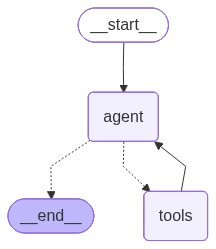

In [42]:
# Show
from IPython.display import Image, display
display(Image(agent_graph.get_graph(xray=True).draw_mermaid_png()))



In [43]:
# Run the graph asynchronously
response = await agent_graph.ainvoke(inputs)

# LangGraph updates the message list state. The final answer is the last message.
final_answer = response["messages"][-1]
print("\n--- Agent Response ---")
print(final_answer.content)


--- Agent Response ---
LangGraph is a framework for building stateful, multi‑agent applications using graphs of LLMs and tools.  
I have access to the `search_web` and `github_file` tools to retrieve information.


# importing mcp from mpc.o

In [54]:
from langchain_mcp_adapters.client import  MultiServerMCPClient

kiwiClient = MultiServerMCPClient(
    {
        "travel_server":{
            "transport": "streamable_http",
            "url": "https://mcp.kiwi.com"
        }
    }
)

tools = await kiwiClient.get_tools()

print(tools)

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [55]:
# 2. Download the tool objects from the server
tools = await kiwiClient.get_tools()

In [56]:
tools

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [75]:
from langchain_mcp_adapters.client import  MultiServerMCPClient

kiwiClient = MultiServerMCPClient(
    {
        "travel_server":{
            "transport": "streamable_http",
            "url": "https://mcp.kiwi.com"
        }
    }
)

tools = await kiwiClient.get_tools()

print(tools)

# 2. Download the tool objects from the server
tools = await kiwiClient.get_tools()

if not tools:
    print("No tools returned from the server.")
    

# 3. Print names to see what Kiwi offers (e.g., 'search_flights')
print("Available Tools:")
for t in tools:
    print(f"- {t.name}: {t.description}")

# 4. Trigger the first tool manually with a sample query dictionary
# (Adjust the arguments below to match what your printed tool expects!)
sample_tool = tools[0]
print(f"\n🚀 Executing tool: '{sample_tool.name}'...")

sample_arguments = {
        "flyFrom": "PRG",
        "flyTo": "BCN",
        "departureDate": "2026-08-25"
    }


try:
    # Use .ainvoke() to trigger the tool with your argument variables
    result = await sample_tool.ainvoke(sample_arguments)
    print("\n--- Tool Response Received ---")
    print(result)
except Exception as e:
    print(f"Error running tool: {e}")

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [63]:
result

[{'type': 'text',
  'text': '{\n  "query": "latest LangGraph features",\n  "follow_up_questions": null,\n  "answer": null,\n  "images": [],\n  "results": [\n    {\n      "url": "https://medium.com/@romerorico.hugo/langgraph-1-0-released-no-breaking-changes-all-the-hard-won-lessons-8939d500ca7c",\n      "title": "LangGraph 1.0: Changes Guide for AI Engineers - Medium",\n      "content": "LangGraph 1.0 released in October 2025. Discover production-ready features: durable execution, streaming, human oversight & memory",\n      "score": 0.74697095,\n      "raw_content": null\n    },\n    {\n      "url": "https://www.reddit.com/r/LangChain/comments/1njlqfq/new_langgraph_and_langchain_v1",\n      "title": "New langgraph and langchain v1 - Reddit",\n      "content": "The LangChain team dropped new features last week. Here\'s a quick look at what\'s new: New create_agent Primitive: Easily create agents with",\n      "score": 0.7018975,\n      "raw_content": null\n    },\n    {\n      "url": "h

In [72]:
print(sample_tool.get_input_schema().model_json_schema())

{'$defs': {'ToolCall': {'description': 'Represents an AI\'s request to call a tool.\n\nExample:\n    ```python\n    {"name": "foo", "args": {"a": 1}, "id": "123"}\n    ```\n\n    This represents a request to call the tool named `\'foo\'` with arguments\n    `{"a": 1}` and an identifier of `\'123\'`.\n\n!!! note "Factory function"\n\n    `tool_call` may also be used as a factory to create a `ToolCall`. Benefits\n    include:\n\n    * Required arguments strictly validated at creation time', 'properties': {'name': {'title': 'Name', 'type': 'string'}, 'args': {'additionalProperties': True, 'title': 'Args', 'type': 'object'}, 'id': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'title': 'Id'}, 'type': {'const': 'tool_call', 'title': 'Type', 'type': 'string'}}, 'required': ['name', 'args', 'id'], 'title': 'ToolCall', 'type': 'object'}}, 'anyOf': [{'type': 'string'}, {'additionalProperties': True, 'type': 'object'}, {'$ref': '#/$defs/ToolCall'}], 'title': 'search-flight_input'}


In [74]:
import json

print(
    json.dumps(
        sample_tool.get_input_schema().model_json_schema(),
        indent=2
    )
)

{
  "$defs": {
    "ToolCall": {
      "description": "Represents an AI's request to call a tool.\n\nExample:\n    ```python\n    {\"name\": \"foo\", \"args\": {\"a\": 1}, \"id\": \"123\"}\n    ```\n\n    This represents a request to call the tool named `'foo'` with arguments\n    `{\"a\": 1}` and an identifier of `'123'`.\n\n!!! note \"Factory function\"\n\n    `tool_call` may also be used as a factory to create a `ToolCall`. Benefits\n    include:\n\n    * Required arguments strictly validated at creation time",
      "properties": {
        "name": {
          "title": "Name",
          "type": "string"
        },
        "args": {
          "additionalProperties": true,
          "title": "Args",
          "type": "object"
        },
        "id": {
          "anyOf": [
            {
              "type": "string"
            },
            {
              "type": "null"
            }
          ],
          "title": "Id"
        },
        "type": {
          "const": "tool_call",


In [76]:
sample_tool.get_input_schema().model_json_schema()

{'$defs': {'ToolCall': {'description': 'Represents an AI\'s request to call a tool.\n\nExample:\n    ```python\n    {"name": "foo", "args": {"a": 1}, "id": "123"}\n    ```\n\n    This represents a request to call the tool named `\'foo\'` with arguments\n    `{"a": 1}` and an identifier of `\'123\'`.\n\n!!! note "Factory function"\n\n    `tool_call` may also be used as a factory to create a `ToolCall`. Benefits\n    include:\n\n    * Required arguments strictly validated at creation time',
   'properties': {'name': {'title': 'Name', 'type': 'string'},
    'args': {'additionalProperties': True, 'title': 'Args', 'type': 'object'},
    'id': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'title': 'Id'},
    'type': {'const': 'tool_call', 'title': 'Type', 'type': 'string'}},
   'required': ['name', 'args', 'id'],
   'title': 'ToolCall',
   'type': 'object'}},
 'anyOf': [{'type': 'string'},
  {'additionalProperties': True, 'type': 'object'},
  {'$ref': '#/$defs/ToolCall'}],
 'title': 'sea

In [77]:
for tool in tools:
    print("=" * 80)
    print("NAME:", tool.name)
    print("DESCRIPTION:", tool.description)

NAME: search-flight
DESCRIPTION: 
# Search for a flight

## Description

Uses the Kiwi API to search for available flights between two locations on a specific date.

## How it works

The tool will:
1. Search for matching locations to resolve airport codes
2. Find available flights for the specified route and date range

## Method

Call this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.

You should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest 'totalDurationInSeconds') and the rest (those that could still be interesting).

Always display for each flight in order:
  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")
  - In the 2nd column: The departure and arrival dates & times in the local timezones, and durat

In [80]:
search_tool

StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates &

In [81]:
try:
    result = await search_tool.ainvoke(
        {
            "flyFrom": "PRG",
            "flyTo": "BCN",
            "departureDate": "2026-08-25"
        }
    )
    print(result)

except Exception as e:
    print(e)
    

MCP error -32602: MCP error -32602: Invalid arguments for tool search-flight: [
  {
    "validation": "regex",
    "code": "invalid_string",
    "message": "date must be in dd/mm/yyyy format",
    "path": [
      "departureDate"
    ]
  }
]


In [86]:
result = await search_tool.ainvoke(
    {
        "flyFrom": "DEL",
        "flyTo": "BNG",
        "departureDate": "25/08/2026"
    }
)

print(result)

[{'type': 'text', 'text': '[\n  {\n    "flyFrom": "DEL",\n    "flyTo": "BKK",\n    "cityFrom": "New Delhi",\n    "cityTo": "Bangkok",\n    "departure": {\n      "utc": "2026-08-24T18:35:00.000Z",\n      "local": "2026-08-25T00:05:00.000"\n    },\n    "arrival": {\n      "utc": "2026-08-25T03:05:00.000Z",\n      "local": "2026-08-25T10:05:00.000"\n    },\n    "totalDurationInSeconds": 30600,\n    "durationInSeconds": 30600,\n    "price": 147,\n    "deepLink": "https://on.kiwi.com/b5z8jE",\n    "currency": "EUR",\n    "layovers": [\n      {\n        "at": "SGN",\n        "city": "Ho Chi Minh City",\n        "cityCode": "SGN",\n        "arrival": {\n          "utc": "2026-08-24T23:35:00.000Z",\n          "local": "2026-08-25T06:35:00.000"\n        },\n        "departure": {\n          "utc": "2026-08-25T01:35:00.000Z",\n          "local": "2026-08-25T08:35:00.000"\n        }\n      }\n    ]\n  },\n  {\n    "flyFrom": "DEL",\n    "flyTo": "BKK",\n    "cityFrom": "New Delhi",\n    "cityTo":

In [87]:
print(result[0]['text'])

[
  {
    "flyFrom": "DEL",
    "flyTo": "BKK",
    "cityFrom": "New Delhi",
    "cityTo": "Bangkok",
    "departure": {
      "utc": "2026-08-24T18:35:00.000Z",
      "local": "2026-08-25T00:05:00.000"
    },
    "arrival": {
      "utc": "2026-08-25T03:05:00.000Z",
      "local": "2026-08-25T10:05:00.000"
    },
    "totalDurationInSeconds": 30600,
    "durationInSeconds": 30600,
    "price": 147,
    "deepLink": "https://on.kiwi.com/b5z8jE",
    "currency": "EUR",
    "layovers": [
      {
        "at": "SGN",
        "city": "Ho Chi Minh City",
        "cityCode": "SGN",
        "arrival": {
          "utc": "2026-08-24T23:35:00.000Z",
          "local": "2026-08-25T06:35:00.000"
        },
        "departure": {
          "utc": "2026-08-25T01:35:00.000Z",
          "local": "2026-08-25T08:35:00.000"
        }
      }
    ]
  },
  {
    "flyFrom": "DEL",
    "flyTo": "BKK",
    "cityFrom": "New Delhi",
    "cityTo": "Bangkok",
    "departure": {
      "utc": "2026-08-24T19:00:00.0

In [88]:
tools

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

In [94]:
print("NAME:", tools[0].name)
print("DESCRIPTION:", tools[0].description)

NAME: search-flight
DESCRIPTION: 
# Search for a flight

## Description

Uses the Kiwi API to search for available flights between two locations on a specific date.

## How it works

The tool will:
1. Search for matching locations to resolve airport codes
2. Find available flights for the specified route and date range

## Method

Call this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.

You should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest 'totalDurationInSeconds') and the rest (those that could still be interesting).

Always display for each flight in order:
  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")
  - In the 2nd column: The departure and arrival dates & times in the local timezones, and durat

# Resource

In [101]:
client = MultiServerMCPClient(
        {
            "my_server": {
                "url":
                    "http://localhost:8000/mcp",
                "transport":
                    "streamable_http",
            }
        }
    )

In [144]:
# get tools
tools = await client.get_tools()
print(tools)

tools = await client.get_tools()
print([t.name for t in tools])

resources = await client.get_resources("my_server")
print(resources)


[]
[]
[Blob 2608274825024]


In [145]:
for res in resources:
        # Blobs store text/bytes and use .as_string() to read them
        print("--- Resource Content ---")
        print(res.as_string())
        
        # Source URI metadata is stored here
        print(f"Source metadata: {res.metadata}") 

--- Resource Content ---
[{"name": "Manish", "id": "EMP101", "joining_date": "2022-03-15", "domain": "AI", "designation": "Software Engineer", "band": "B2", "salary": "80 LPA", "experience": "4 years"}, {"name": "Rahul", "id": "EMP102", "joining_date": "2020-07-10", "domain": "Backend", "designation": "Senior Engineer", "band": "B3", "salary": "18 LPA", "experience": "6 years"}]
Source metadata: {'uri': AnyUrl('employee://all')}


In [ ]:
resource = resources[0]

resource

Blob 2608274825024

In [ ]:
resource.data  # json string

'[{"name": "Manish", "id": "EMP101", "joining_date": "2022-03-15", "domain": "AI", "designation": "Software Engineer", "band": "B2", "salary": "80 LPA", "experience": "4 years"}, {"name": "Rahul", "id": "EMP102", "joining_date": "2020-07-10", "domain": "Backend", "designation": "Senior Engineer", "band": "B3", "salary": "18 LPA", "experience": "6 years"}]'

In [147]:
resource_data = resource[0].data

In [ ]:
employees = json.loads(resource_data)
            

In [150]:
employees

[{'name': 'Manish',
  'id': 'EMP101',
  'joining_date': '2022-03-15',
  'domain': 'AI',
  'designation': 'Software Engineer',
  'band': 'B2',
  'salary': '80 LPA',
  'experience': '4 years'},
 {'name': 'Rahul',
  'id': 'EMP102',
  'joining_date': '2020-07-10',
  'domain': 'Backend',
  'designation': 'Senior Engineer',
  'band': 'B3',
  'salary': '18 LPA',
  'experience': '6 years'}]

In [155]:
employee = next(
            (
                emp
                for emp in employees
                if emp["name"].lower()
                == "rahul"
            ),
            None
        )

In [156]:
employee

{'name': 'Rahul',
 'id': 'EMP102',
 'joining_date': '2020-07-10',
 'domain': 'Backend',
 'designation': 'Senior Engineer',
 'band': 'B3',
 'salary': '18 LPA',
 'experience': '6 years'}

In [200]:
employee_data = (
            json.dumps(employee, indent=2)
            if employee
            else "Not found"
        )

In [201]:
employee_data

'{\n  "name": "Rahul",\n  "id": "EMP102",\n  "joining_date": "2020-07-10",\n  "domain": "Backend",\n  "designation": "Senior Engineer",\n  "band": "B3",\n  "salary": "18 LPA",\n  "experience": "6 years"\n}'

In [202]:
type(employee_data)

str

# prompt

In [ ]:
# Get MCP prompt directly
prompt = await client.get_prompt(
    "my_server",              # server name
    "employee_hr_prompt",     # prompt name
    arguments={
        "employee_name": "Manish",
        "employee_data": """
        {
            "salary": "12 LPA",
            "designation":
            "Software Engineer"
        }
        """,
        "user_question":
        "What is his salary?"
    }
)

In [ ]:
print(prompt[0].content)


You are an HR assistant.

Answer employee-related questions
strictly based on employee data.

Employee Name:
Manish

Employee Data:

        {
            "salary": "12 LPA",
            "designation":
            "Software Engineer"
        }
        

User Question:
What is his salary?

Rules:
- Do not hallucinate
- If employee missing,
  say 'Employee not found'



In [196]:
# Get MCP prompt directly
prompt = await client.get_prompt(
    "my_server",              # server name
    "employee_hr_prompt",     # prompt name
    arguments={
        "employee_name": "Rahul",
        "employee_data": employee_data,
        "user_question":
        "What is his salary?"
    }
)

In [198]:
prompt

[HumanMessage(content='\nYou are an HR assistant.\n\nAnswer employee-related questions\nstrictly based on employee data.\n\nEmployee Name:\nRahul\n\nEmployee Data:\n{\n  "name": "Rahul",\n  "id": "EMP102",\n  "joining_date": "2020-07-10",\n  "domain": "Backend",\n  "designation": "Senior Engineer",\n  "band": "B3",\n  "salary": "18 LPA",\n  "experience": "6 years"\n}\n\nUser Question:\nWhat is his salary?\n\nRules:\n- Do not hallucinate\n- If employee missing,\n  say \'Employee not found\'\n', additional_kwargs={}, response_metadata={})]

In [170]:
prompt_text = (prompt[0].content)

In [171]:
prompt_text

'\nYou are an HR assistant.\n\nAnswer employee-related questions\nstrictly based on employee data.\n\nEmployee Name:\nRahul\n\nEmployee Data:\n{\n  "name": "Rahul",\n  "id": "EMP102",\n  "joining_date": "2020-07-10",\n  "domain": "Backend",\n  "designation": "Senior Engineer",\n  "band": "B3",\n  "salary": "18 LPA",\n  "experience": "6 years"\n}\n\nUser Question:\nWhat is his salary?\n\nRules:\n- Do not hallucinate\n- If employee missing,\n  say \'Employee not found\'\n'

In [172]:
print(prompt_text)


You are an HR assistant.

Answer employee-related questions
strictly based on employee data.

Employee Name:
Rahul

Employee Data:
{
  "name": "Rahul",
  "id": "EMP102",
  "joining_date": "2020-07-10",
  "domain": "Backend",
  "designation": "Senior Engineer",
  "band": "B3",
  "salary": "18 LPA",
  "experience": "6 years"
}

User Question:
What is his salary?

Rules:
- Do not hallucinate
- If employee missing,
  say 'Employee not found'



# final agent with resource and tool only

In [186]:
from typing import TypedDict

import asyncio
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_mcp_adapters.client import MultiServerMCPClient
import os
from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


import os
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")


class State(TypedDict):
    employee_name: str
    question: str
    answer: str

llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={"headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}},
    )

In [ ]:
async def employee_agent(state: State):
    client = MultiServerMCPClient({
        "my_server": {
            "url": "http://localhost:8000/mcp",
            "transport": "streamable_http",
        }
    })
    async with client.session("my_server") as session:
        resource = await session.read_resource("employee://all")
        employees = json.loads(resource.contents[0].text)
        employee = next((emp for emp in employees if emp["name"].lower() == state["employee_name"].lower()), None)
        employee_data = json.dumps(employee, indent=2) if employee else "Not found"
        prompt = await session.get_prompt(
            "employee_hr_prompt",
            arguments={
                "employee_name": state["employee_name"],
                "employee_data": employee_data,
                "user_question": state["question"],
            },
        )

        prompt_text = prompt.messages[0].content.text
        response = llm.invoke(prompt_text)
        return {"answer": response.content}




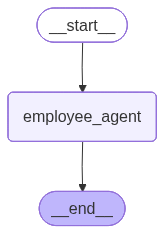

In [188]:
graph = StateGraph(State)
graph.add_node("employee_agent", employee_agent)
graph.add_edge(START, "employee_agent")
graph.add_edge("employee_agent", END)
app = graph.compile()

# Show
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))




In [189]:
async def main():
    result = await app.ainvoke({"employee_name": "Manish", "question": "What is his salary?"})
    print(result["answer"])
    return result

ans = await main()

80 LPA


In [190]:
ans

{'employee_name': 'Manish',
 'question': 'What is his salary?',
 'answer': '80 LPA'}

# same code using StateMessages class

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState  # Built-in state that includes a "messages" key
import json

# 1. We inherit from MessagesState. It automatically provides a list of messages.
# We can still add custom keys if we need specific metadata tracking.
class AgentState(MessagesState):
    employee_name: str 

llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={"headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}},
)

async def employee_agent(state: AgentState):
    client = MultiServerMCPClient({
        "my_server": {
            "url": "http://localhost:8000/mcp",
            "transport": "streamable_http",
        }
    })
    
    async with client.session("my_server") as session:
        resource = await session.read_resource("employee://all")
        employees = json.loads(resource.contents[0].text)
        employee = next((emp for emp in employees if emp["name"].lower() == state["employee_name"].lower()), None)
        employee_data = json.dumps(employee, indent=2) if employee else "Not found"
        
        # Pull the last user question directly from the messages history
        last_user_message = state["messages"][-1].content
        
        prompt = await session.get_prompt(
            "employee_hr_prompt",
            arguments={
                "employee_name": state["employee_name"],
                "employee_data": employee_data,
                "user_question": last_user_message,
            },
        )
        
        # Since ChatOllama supports message lists, we can pass it natively
        # or stick to your string format:
        prompt_text = prompt.messages[0].content.text
        
        # Invoke the LLM
        response = llm.invoke(prompt_text)
        
        # LangGraph's MessagesState will automatically APPEND this message 
        # to the history because of the built-in 'add_messages' reducer.
        return {"messages": [AIMessage(content=response.content)]}

# Build the graph using AgentState
graph = StateGraph(AgentState)
graph.add_node("employee_agent", employee_agent)
graph.add_edge(START, "employee_agent")
graph.add_edge("employee_agent", END)
app = graph.compile()

async def main():
    # We pass a HumanMessage object inside the messages list
    inputs = {
        "employee_name": "Manish", 
        "messages": [HumanMessage(content="What is his salary?")]
    }
    
    result = await app.ainvoke(inputs)
    
    # The final answer is the last message in the state
    print(result["messages"][-1].content)
    return result

ans = await main()

# modification in server to fetch resourc by id

In [214]:
client = MultiServerMCPClient(
        {
            "my_server": {
                "url":
                    "http://localhost:8000/mcp",
                "transport":
                    "streamable_http",
            }
        }
    )

In [215]:
resources = await client.get_resources("my_server")
print(resources)


[Blob 2608230458592]


In [218]:
resources[0].data

'[{"name": "Manish", "id": "EMP101", "joining_date": "2022-03-15", "domain": "AI", "designation": "Software Engineer", "band": "B2", "salary": "80 LPA", "experience": "4 years"}, {"name": "Rahul", "id": "EMP102", "joining_date": "2020-07-10", "domain": "Backend", "designation": "Senior Engineer", "band": "B3", "salary": "18 LPA", "experience": "6 years"}]'

In [220]:
for res in resources:
        # Blobs store text/bytes and use .as_string() to read them
        print("--- Resource Content ---")
        print(res.as_string())
        
        # Source URI metadata is stored here
        print(f"Source metadata: {res.metadata}") 

--- Resource Content ---
[{"name": "Manish", "id": "EMP101", "joining_date": "2022-03-15", "domain": "AI", "designation": "Software Engineer", "band": "B2", "salary": "80 LPA", "experience": "4 years"}, {"name": "Rahul", "id": "EMP102", "joining_date": "2020-07-10", "domain": "Backend", "designation": "Senior Engineer", "band": "B3", "salary": "18 LPA", "experience": "6 years"}]
Source metadata: {'uri': AnyUrl('employee://all')}


In [223]:
import asyncio
# Ensure MultiServerMCPClient is imported
# from your_module import MultiServerMCPClient 

async def test_resource_fetching():
    # 1. Initialize Client
    client = MultiServerMCPClient({
        "my_server": {
            "url": "http://localhost:8000/mcp",
            "transport": "streamable_http",
        }
    })
    
    async with client.session("my_server") as session:
        print("--- Testing Resource: employee://all ---")
        try:
            resource_all = await session.read_resource("employee://all")
            print("Successfully fetched ALL employees:")
            print(resource_all.contents[0].text)
        except Exception as e:
            print(f"Error fetching employee://all: {e}")
            
        print("\n--- Testing Resource: employee://EMP101 ---")
        try:
            emp_id = "EMP101"
            # We are manually calling the template with a specific ID
            resource_id = await session.read_resource(f"employee://{emp_id}")
            print("Successfully fetched EMP101:")
            print(resource_id.contents[0].text)
        except Exception as e:
            print(f"Error fetching employee://EMP101: {e}")

# Run the test
await test_resource_fetching()

--- Testing Resource: employee://all ---
Successfully fetched ALL employees:
[{"name": "Manish", "id": "EMP101", "joining_date": "2022-03-15", "domain": "AI", "designation": "Software Engineer", "band": "B2", "salary": "80 LPA", "experience": "4 years"}, {"name": "Rahul", "id": "EMP102", "joining_date": "2020-07-10", "domain": "Backend", "designation": "Senior Engineer", "band": "B3", "salary": "18 LPA", "experience": "6 years"}]

--- Testing Resource: employee://EMP101 ---
Successfully fetched EMP101:
{
  "name": "Manish",
  "id": "EMP101",
  "joining_date": "2022-03-15",
  "domain": "AI",
  "designation": "Software Engineer",
  "band": "B2",
  "salary": "80 LPA",
  "experience": "4 years"
}


 .

Here is a comprehensive summary of why the Model Context Protocol (MCP) decouples **Prompts** and **Resources** onto a centralized server rather than embedding them directly inside your LangGraph application code.

---

## 1. Core Definitions: Prompts vs. Resources

In the MCP ecosystem, Prompts and Resources serve completely different operational functions:

* **Prompts (The Instructions):** Pre-engineered text templates, personas, or system instructions that guide how an LLM behaves, parses inputs, and formats its output (e.g., `employee_hr_prompt`).
* **Resources (The Context):** The raw background data, documents, log files, or database entries that the LLM needs to reference to answer a specific question accurately (e.g., `employee://all` or `employee://EMP101`).

---

## 2. Why Keep Them on an MCP Server? (The Architecture)

Moving these elements out of your local application code and onto a central MCP server provides critical production-grade benefits across four categories:

### A. Zero-Downtime Updates (Hot Swapping)

* **The Utility:** In production, prompt engineering is highly iterative. If a prompt is hardcoded in your application, changing a single instruction requires a complete code deployment cycle (pull request, CI/CD pipeline, container rebuild, server rolling restart).
* **The MCP Advantage:** Updating a prompt template directly on the MCP server changes the behavior of your LangGraph agents **instantly** without a single second of application downtime.

### B. Enterprise Security and Data Boundaries

* **The Utility:** A core rule of production AI is that the LLM orchestrator should not have direct, raw access to internal databases or file systems.
* **The MCP Advantage:** The MCP server acts as a **secure data guard**. It handles database connections, authentication, and row-level access control. The LangGraph application simply requests `employee://EMP101`, and the server decides if that specific request is authorized before stripping out sensitive metadata and returning clean text.

### C. Application-Controlled Context (Reducing Hallucinations)

* **The Utility:** If you provide an LLM with access to general database "Tools," it has to decide *if* and *when* to execute them, introducing risks of hallucination, missed function calls, or data leaks.
* **The MCP Advantage:** **Resources are Application-Controlled.** Your python code handles the flow logic—fetching the specific resource and passing it safely to the prompt—keeping the LLM on a strict leash and guaranteeing it answers based on precise data.

### D. Single Source of Truth (Multi-Agent Scale)

* **The Utility:** In large companies, you might have multiple AI assistants running concurrently (one in Python/LangGraph, one in TypeScript/Next.js, and one on Claude Desktop).
* **The MCP Advantage:** Instead of duplicating, copying, and pasting prompt strings or data parsing functions across three different code repositories, every single agent points to the exact same MCP server.

---

## Summary Table

| Feature / Metric | Without MCP (Local Code) | With MCP Server | Production Impact |
| --- | --- | --- | --- |
| **Prompt Tuning** | Requires code redeployment, docker builds, and pipeline delays. | Updated dynamically on the server in real-time. | High Agility & Zero Downtime. |
| **Data Security** | Application requires direct DB credentials / file path access. | Server exposes clean, read-only `resource://` URIs. | Robust enterprise governance and auditing. |
| **Code Duplication** | Same prompt must be hardcoded across Python/JS codebases. | Shared endpoint for all agents and frameworks. | High maintainability. |
| **Performance** | Local RAM speed (fastest). | Network API/Stdio call latency. | *Mitigated easily via Client-side caching (TTL).* |

In [225]:
"."

'.'

# json basics

Here is the complete summary of everything we have discussed about JSON and Python's `json` module, broken down into clear, digestible points:

---

## 1. What JSON Actually Is

* **A Text Format, Not a Data Type:** JSON (JavaScript Object Notation) is a standardized, language-independent **data format**. In Python, raw JSON is always just a standard string (`str`).
* **The Universal Language:** It acts as a bridge between different programming languages. A Python dictionary can't be read by JavaScript or Java, but a JSON string can be read by any language.
* **Strict Rules:** JSON looks like a Python dictionary but has stricter rules: it *must* use double quotes (`"`), keys *must* be strings, and it uses lowercase `true`, `false`, and `null`.

---

## 2. Python Dict vs. JSON String

* **Python `dict`:** A live object sitting in your computer's RAM. You can interact with it, modify it, and look up keys instantly.
* **JSON String:** A flat, static string of text used to store data in a file or send it over the internet (like fetching data from a server). You cannot look up keys until you convert it back to a dictionary.

---

## 3. The Python `json` Module Methods

Python provides four main functions to translate data back and forth. They are divided by whether you are working with **Files** or **Strings**.

### Working with Files (No "s" at the end)

* **`json.dump(obj, file)`:** **Dumps** a Python object (like a dict) *into* a physical `.json` file. (Requires opening a file in write mode `"w"`).
* **`json.load(file)`:** **Loads** raw JSON data *from* a physical `.json` file and converts it into a native Python dictionary. (Requires opening a file in read mode `"r"`).

### Working with Strings (Has an "s" at the end for "String")

* **`json.dumps(obj)`:** Converts a Python object into a JSON-formatted **s**tring. (Great for preparing data to send to a server).
* **`json.loads(string)`:** Takes a JSON **s**tring (like the raw text response you get from a web server) and loads it into a Python dictionary so your code can use it.

---

## 4. The Core Process: Serialization vs. Deserialization

* **Serialization (`dump` / `dumps`):** The process of translating a live Python memory object into a flat JSON text format so it can travel or be saved.
* **Deserialization (`load` / `loads`):** The process of taking that flat JSON text and reconstructing it back into a live Python object.

In [206]:
import json

# 1. Create some Python data (a dictionary)
user_data = {
    "name": "Alice",
    "age": 30,
    "is_member": True,
    "skills": ["Python", "Data Science"]
}

# python object
user_data

{'name': 'Alice',
 'age': 30,
 'is_member': True,
 'skills': ['Python', 'Data Science']}

In [207]:
type(user_data)

dict

In [208]:
# 2. Open a file in write mode ('w') and use json.dump
with open("data.json", "w") as json_file:
    # indent=4 makes the JSON file pretty and easy to read
    json.dump(user_data, json_file, indent=4) 

print("Data successfully saved to data.json!")

Data successfully saved to data.json!


In [ ]:
# output
{
    "name": "Alice",
    "age": 30,
    "is_member": true,
    "skills": [
        "Python",
        "Data Science"
    ]
}

In [209]:
import json

# 1. Open the existing JSON file in read mode ('r')
with open("data.json", "r") as json_file:
    # 2. Use json.load to read the file object
    loaded_data = json.load(json_file)

# 3. Now 'loaded_data' is a standard Python dictionary
print(type(loaded_data))  # Output: <class 'dict'>
print(loaded_data["name"])  # Output: Alice
print(loaded_data["skills"][0])  # Output: Python

<class 'dict'>
Alice
Python


In [210]:
# Simulated response from a server API
server_response = '{"username": "coder123", "login_count": 5}'

print(type(server_response))  
# Output: <class 'str'>

<class 'str'>


In [211]:
import json

# Parsing the JSON string
data = json.loads(server_response)

print(type(data))  
# Output: <class 'dict'>

# Now you can use it!
print(data["username"])  # Output: coder123

<class 'dict'>
coder123
